In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [2]:
df = pd.read_csv("data/dataset.csv")

In [3]:
df["clean_text"] = df["clean_text"].fillna("")
X = df["clean_text"]
y_style = df["style"]
y_tone = df["tone"]

X_train_style, X_test_style, y_train_style, y_test_style = train_test_split(
    X, y_style, test_size=0.2, random_state=42, stratify=y_style
)

X_train_tone, X_test_tone, y_train_tone, y_test_tone = train_test_split(
    X, y_tone, test_size=0.2, random_state=42, stratify=y_tone
)

pipeline = Pipeline(
    [("tfidf", TfidfVectorizer()), ("classifier", LinearSVC())]
)

param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "classifier__C": [0.1, 1, 10],
}


Tuning STYLE model...

Fitting 5 folds for each of 18 candidates, totalling 90 fits



Cross-validation Style F1 (weighted): 0.9183
Best STYLE params:
{'classifier__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 3)}

STYLE F1-score: 0.8860

STYLE Classification Report:

              precision    recall  f1-score   support

    academic       0.97      0.93      0.95        40
    business       0.71      0.85      0.77        40
      formal       0.88      0.72      0.79        40
    informal       0.90      0.95      0.93        40
    literaly       1.00      0.97      0.99        40

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



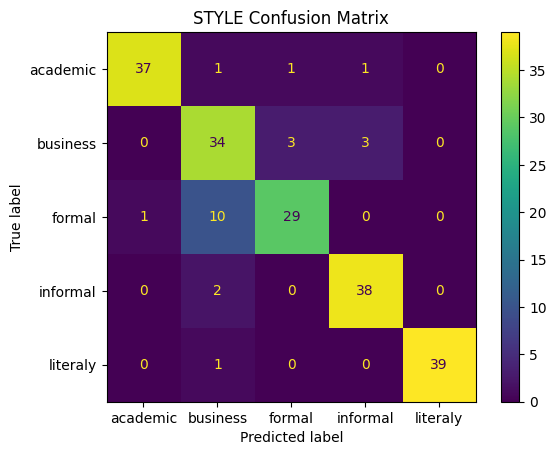


Saved style_model.joblib


In [4]:
print("\nTuning STYLE model...\n")

grid_style = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

grid_style.fit(X_train_style, y_train_style)
best_style_model = grid_style.best_estimator_
print(f"\nCross-validation Style F1 (weighted): {grid_style.best_score_:.4f}")

print("Best STYLE params:")
print(grid_style.best_params_)

style_predictions = best_style_model.predict(X_test_style)
style_f1 = f1_score(y_test_style, style_predictions, average="weighted")
print(f"\nSTYLE F1-score: {style_f1:.4f}")

print("\nSTYLE Classification Report:\n")
print(classification_report(y_test_style, style_predictions))

style_cm = confusion_matrix(y_test_style, style_predictions)
disp_style = ConfusionMatrixDisplay(
    confusion_matrix=style_cm, display_labels=best_style_model.classes_
)
disp_style.plot()
plt.title("STYLE Confusion Matrix")
plt.show()

os.makedirs("saving", exist_ok=True)

with open("saving/style_model.joblib", "wb") as f:
    joblib.dump(best_style_model, f)
print("\nSaved style_model.joblib")


Tuning TONE model...

Fitting 5 folds for each of 18 candidates, totalling 90 fits



Cross-validation Tone F1 (weighted): 0.9496
Best TONE params:
{'classifier__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}

TONE F1-score: 0.9353

TONE Classification Report:

              precision    recall  f1-score   support

  aggressive       1.00      0.90      0.95        40
    friendly       0.93      0.93      0.93        40
     neutral       0.91      0.97      0.94        40
   sarcastic       0.88      0.93      0.90        40
      urgent       0.97      0.95      0.96        40

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



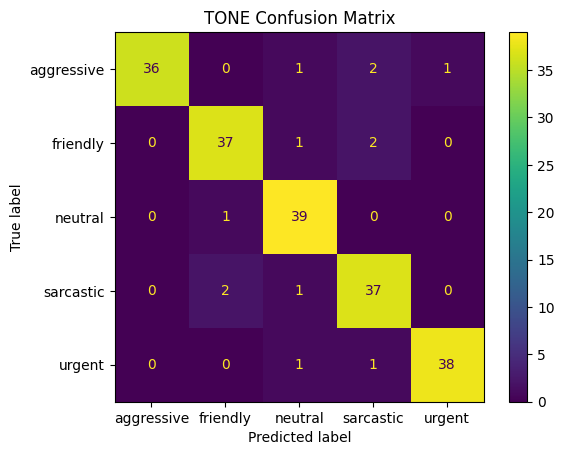


Saved tone_model.joblib


In [5]:
print("\nTuning TONE model...\n")

grid_tone = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

grid_tone.fit(X_train_tone, y_train_tone)
best_tone_model = grid_tone.best_estimator_
print(f"\nCross-validation Tone F1 (weighted): {grid_tone.best_score_:.4f}")

print("Best TONE params:")
print(grid_tone.best_params_)

tone_predictions = best_tone_model.predict(X_test_tone)
tone_f1 = f1_score(y_test_tone, tone_predictions, average="weighted")
print(f"\nTONE F1-score: {tone_f1:.4f}")

print("\nTONE Classification Report:\n")
print(classification_report(y_test_tone, tone_predictions))

tone_cm = confusion_matrix(y_test_tone, tone_predictions)
disp_tone = ConfusionMatrixDisplay(
    confusion_matrix=tone_cm, display_labels=best_tone_model.classes_
)
disp_tone.plot()
plt.title("TONE Confusion Matrix")
plt.show()

os.makedirs("saving", exist_ok=True)

with open("saving/tone_model.joblib", "wb") as f:
    joblib.dump(best_tone_model, f)
print("\nSaved tone_model.joblib")

## 2D Visualization of Text Samples (t-SNE)

To better understand how styles and tones are distributed in the feature space, we can project the high-dimensional TF-IDF vectors (5,000 features) onto a 2-dimensional plane. We use **TruncatedSVD** to reduce the dimensionality to 50 (since TF-IDF produces a sparse matrix, SVD is preferred over PCA), followed by **t-SNE** (t-Distributed Stochastic Neighbor Embedding) to project the data into a 2D space.

Running t-SNE dimensionality reduction for 2D visualization...


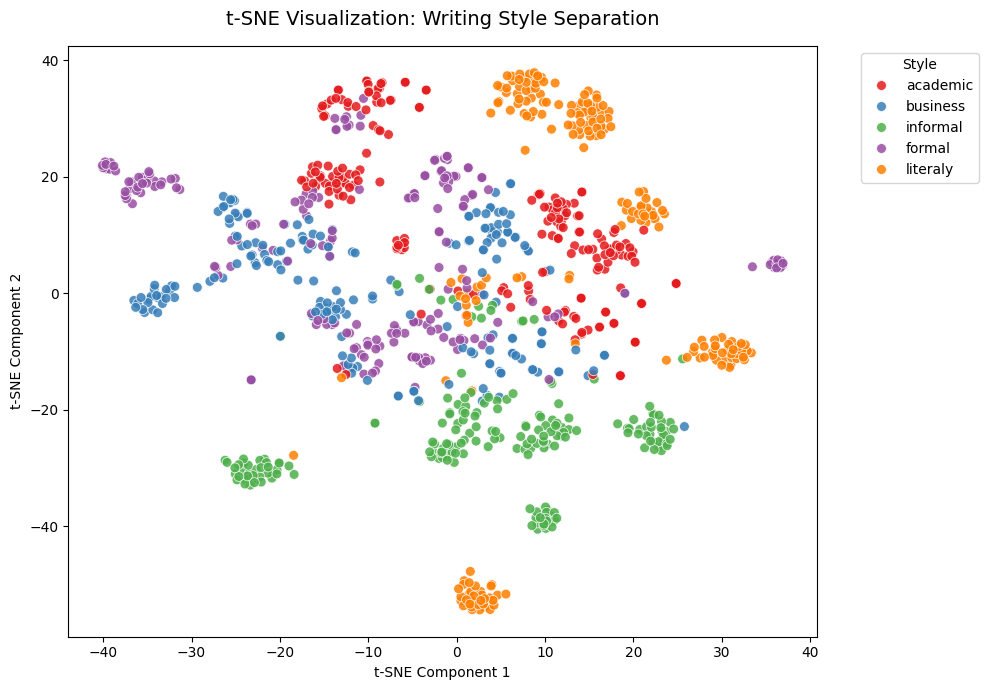

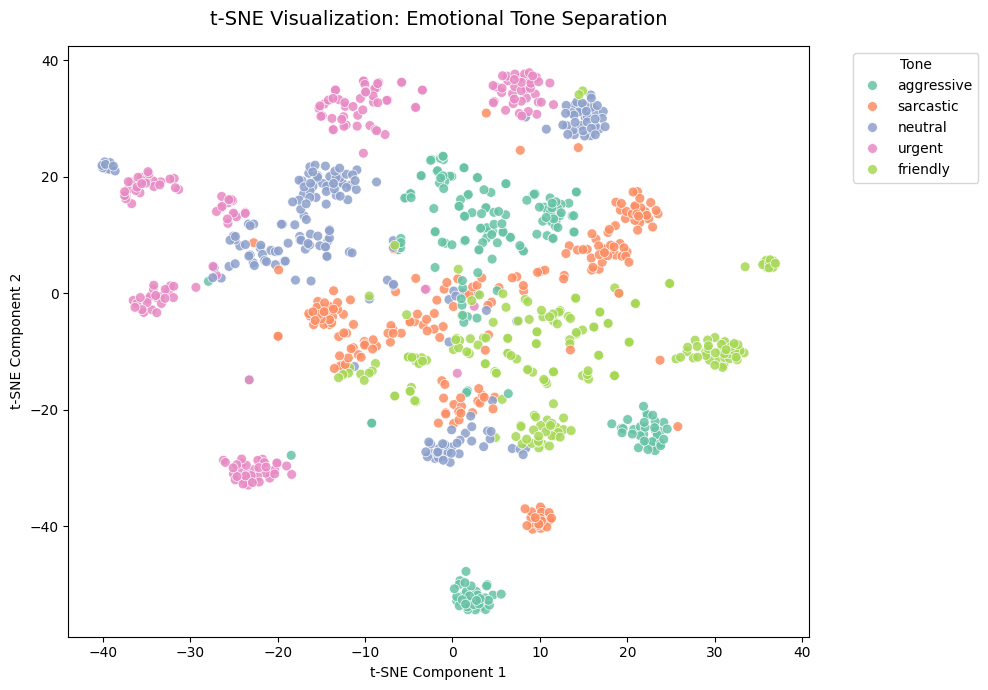

In [ ]:
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD

print("Running t-SNE dimensionality reduction for 2D visualization...")

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 3))
X_tfidf = tfidf.fit_transform(X)

svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, init='random')
X_tsne = tsne.fit_transform(X_svd)

df_tsne = pd.DataFrame({
    "t-SNE Component 1": X_tsne[:, 0],
    "t-SNE Component 2": X_tsne[:, 1],
    "Style": y_style,
    "Tone": y_tone
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="t-SNE Component 1", y="t-SNE Component 2",
    hue="Style",
    palette="Set1",
    data=df_tsne,
    alpha=0.85,
    edgecolor="w",
    s=50
)
plt.title("t-SNE Visualization: Writing Style Separation", fontsize=14, pad=15)
plt.legend(title="Style", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("saving/style_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="t-SNE Component 1", y="t-SNE Component 2",
    hue="Tone",
    palette="Set2",
    data=df_tsne,
    alpha=0.85,
    edgecolor="w",
    s=50
)
plt.title("t-SNE Visualization: Emotional Tone Separation", fontsize=14, pad=15)
plt.legend(title="Tone", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("saving/tone_tsne.png", dpi=150, bbox_inches="tight")
plt.show()